In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_dir = "..\\data\\FJ\\FI01X1\\FI01X1_ch"

dataset_dir = Path(data_dir)
files = sorted(dataset_dir.glob("*.npz"))
if not files:
    raise RuntimeError("No .npz files found")

In [3]:
sample = np.load(files[0])

In [4]:
dataset = []
for f in files:
    sample = np.load(f)
    dataset.append(sample['values'])
print(len(dataset))

620


In [5]:
point_dim = len(dataset[0])

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)
dataset = [scaler.fit_transform(h.reshape(-1, 1)).flatten() for h in dataset]

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [8]:
t = torch.rand(20)
x = nn.Linear(20, 40)(t)
print(F.relu(x))

tensor([0.0000, 0.0000, 0.2369, 0.0000, 0.0000, 0.0000, 0.0000, 0.2498, 0.2518,
        0.0000, 0.0000, 0.0381, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0379, 0.0000, 0.0271, 0.0000, 0.1734, 0.4519, 0.0000, 0.6188,
        0.0000, 0.0000, 0.0000, 0.0000, 0.7486, 0.0221, 0.1847, 0.5912, 0.0000,
        0.0000, 0.1321, 0.3388, 0.4983], grad_fn=<ReluBackward0>)


In [9]:
pt = dataset[0]
pt = torch.tensor(pt).float()

pt = pt.reshape(1, 1, 96)

In [10]:
conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2)
conv2 = nn.Conv1d(in_channels=4, out_channels=16, kernel_size=4, stride=3)
conv3 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=4, stride=3)
torch.flatten(conv3(conv2(conv1(pt)))).shape

torch.Size([128])

In [11]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # self.conv1 = nn.Conv1d(in_channels=1, out_channels=3, kernel_size=3, stride=2)
        # self.conv1 = nn.Conv1d(in_channels=3, out_channels=9, kernel_size=3, stride=2)
        # self.conv1 = nn.Conv1d(in_channels=9, out_channels=16, kernel_size=3, stride=2)
        # self.fc = nn.Linear()
        self.fc1 = nn.Linear(20, 40)
        self.fc2 = nn.Linear(40, 80)
        self.fc3 = nn.Linear(80, 96)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.sigmoid(self.fc3(x))
        return x
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2)
        self.conv2 = nn.Conv1d(in_channels=4, out_channels=16, kernel_size=4, stride=3)
        self.conv3 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=4, stride=3)
        self.fc = nn.Linear(128, 1)

        #self.fc1 = nn.Linear(96, 80)
        #self.fc2 = nn.Linear(80, 60)
        #self.fc3 = nn.Linear(60, 40)
        #self.fc4 = nn.Linear(40, 1)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, start_dim=1)
        x = F.sigmoid(self.fc(x))
        return x

In [12]:
gen = Generator()
disc = Discriminator()

In [13]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

class HistogramDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        hist = self.data[idx]
        hist = torch.tensor(hist, dtype=torch.float32)
        return hist

ds = HistogramDataset(dataset)

dataloader = DataLoader(
    ds,
    batch_size=16,
    shuffle=False,
    num_workers=0 
)

In [14]:
lr = 0.0002
beta1 = 0.5
num_epochs = 30
latent_dim = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
criterion = nn.BCELoss()
criterion_2 = nn.BCELoss()
optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = torch.optim.Adam(disc.parameters(), lr=lr, betas=(beta1, 0.999))

In [16]:
losses_D = []
losses_G = []

for epoch in range(num_epochs):
    for i, real_data in enumerate(dataloader):

        batch_size = real_data.size(0)
        
        real_labels = torch.ones(batch_size, 1, device=device) 
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # disc
        disc.zero_grad()
        real_data = real_data.reshape(batch_size, 1, point_dim)    
        
        #  real data
        outputs_real = disc(real_data) # 16 x 96
        loss_real = criterion(outputs_real, real_labels)

        # generated data
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_data = gen(z) # output: 16 x 96
        fake_data = fake_data.unsqueeze(1) # shape 16 x 1 x 96
        
        outputs_fake = disc(fake_data.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward(retain_graph=True)
        optimizer_D.step()

        # gen
        gen.zero_grad()
        outputs = disc(fake_data)
        
        # gen tricking disc
        loss_G = criterion(outputs, real_labels)
        loss_G.backward()
        optimizer_G.step()
    
    losses_D.append(loss_D.detach().numpy())
    losses_G.append(loss_G.detach().numpy())
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

Epoch [1/30] Loss D: 1.3752, Loss G: 0.6928
Epoch [2/30] Loss D: 1.3716, Loss G: 0.6688
Epoch [3/30] Loss D: 1.3765, Loss G: 0.6658
Epoch [4/30] Loss D: 1.3793, Loss G: 0.6778
Epoch [5/30] Loss D: 1.3893, Loss G: 0.6829
Epoch [6/30] Loss D: 1.3894, Loss G: 0.6933
Epoch [7/30] Loss D: 1.3920, Loss G: 0.6944
Epoch [8/30] Loss D: 1.3761, Loss G: 0.6907
Epoch [9/30] Loss D: 1.3495, Loss G: 0.6788
Epoch [10/30] Loss D: 1.3499, Loss G: 0.6677
Epoch [11/30] Loss D: 1.3254, Loss G: 0.6897
Epoch [12/30] Loss D: 1.2904, Loss G: 0.7046
Epoch [13/30] Loss D: 1.3149, Loss G: 0.6930
Epoch [14/30] Loss D: 1.3469, Loss G: 0.6968
Epoch [15/30] Loss D: 1.3767, Loss G: 0.7047
Epoch [16/30] Loss D: 1.3784, Loss G: 0.7037
Epoch [17/30] Loss D: 1.4039, Loss G: 0.6604
Epoch [18/30] Loss D: 1.2964, Loss G: 0.6932
Epoch [19/30] Loss D: 1.2409, Loss G: 0.6928
Epoch [20/30] Loss D: 1.1978, Loss G: 0.7093
Epoch [21/30] Loss D: 1.2431, Loss G: 0.6907
Epoch [22/30] Loss D: 1.3506, Loss G: 0.7163
Epoch [23/30] Loss 

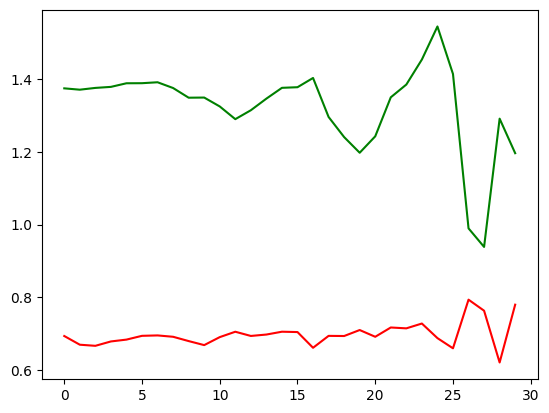

In [17]:
plt.plot(range(len(losses_D)), losses_D, color='green')
plt.plot(range(len(losses_G)), losses_G, color='red')
plt.show()

In [23]:
scores = []

with torch.no_grad():
    for hist in dataloader:
        #hist = torch.tensor(hist, dtype=float)
        hist = hist.unsqueeze(1)
        score = disc(hist)
        for s in score:
            scores.append(s)       

In [24]:
len(scores)

620

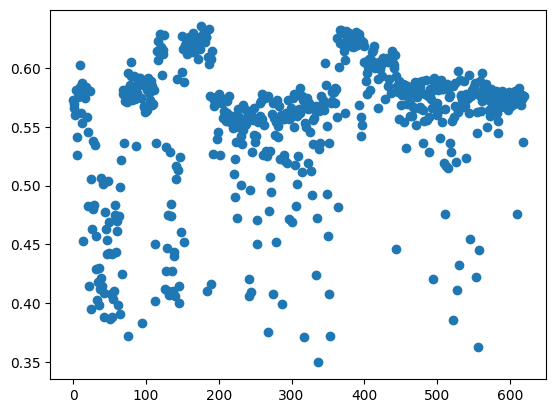

In [25]:
plt.scatter(range(len(scores)), scores)

In [26]:
max(scores)

tensor([0.6356])

In [22]:
outliers_linear = outliers
outliers_linear

NameError: name 'outliers' is not defined

In [27]:
idx = outliers[0]
out = dataset[idx]
normal_pt = dataset[200]
#plt.bar(range(len(out)), height=out)
plt.bar(range(len(normal_pt)), height=normal_pt)

NameError: name 'outliers' is not defined